In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Optional (we’ll use later)
# pip install xgboost
from xgboost import XGBRegressor


In [6]:
# Load carrot rolling-window dataset
file_path = "../datasets/carrot_complete_growth_dataset.xlsx"
df = pd.read_excel(file_path)

df.head()


,Date,Carrot_Avg_Price,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,Average of tempmin_avg_75d,Average of temp_avg_75d,Average of windspeed_avg_75d,Average of precip_avg_75d,Average of humidity_avg_75d,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d
0,2020-06-15,100.00 - 130.00,100,130,500,4160,180,300,1000,29.560746,19.703947,15.954167,23.262500,14.764912,6.522357,81.799781,67.789693,232.072149,32.972588,20.062939
1,2020-06-16,100.00 - 120.00,100,120,500,4160,180,300,1000,29.564693,19.762061,15.990789,23.277193,14.732456,6.523658,81.956360,67.951096,231.635307,33.113816,20.024781
2,2020-06-17,100.00 - 130.00,100,130,500,4160,180,300,1000,29.559430,19.836842,16.014912,23.295175,14.854386,6.538441,82.179825,68.410307,230.398026,33.246711,19.917982
3,2020-06-18,90.00 - 120.00,90,120,500,4160,180,300,1000,29.558553,19.868202,16.049781,23.313596,15.001316,6.538781,82.225000,68.973465,229.512061,33.292982,19.842325
4,2020-06-19,70.00 - 100.00,70,100,500,4160,180,300,1000,29.588816,19.871711,16.069518,23.343202,15.048465,6.503066,82.108333,69.005921,229.419956,33.393421,19.834868


In [7]:
df.shape


(1334, 20)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               1334 non-null   datetime64[ns]
 1   Carrot_Avg_Price                   1334 non-null   object        
 2   Carrot_Min_Price                   1334 non-null   int64         
 3   Carrot_Max_Price                   1334 non-null   int64         
 4   Labour Cost                        1334 non-null   int64         
 5   Transportation Cost                1334 non-null   int64         
 6   Fertilizer (Urea)                  1334 non-null   int64         
 7   Fertilizer(MOP)                    1334 non-null   int64         
 8   Plantation Crop                    1334 non-null   int64         
 9   Average of tempmax_avg_75d         1334 non-null   float64       
 10  Average of dew_avg_75d             1

In [9]:
df.describe()


,Date,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,Average of tempmin_avg_75d,Average of temp_avg_75d,Average of windspeed_avg_75d,Average of precip_avg_75d,Average of humidity_avg_75d,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d
count,1334,1334.000000,1334.000000,1334.000000,1334.000000,1334.0,1334.0,1334.0,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000
mean,2022-12-05 23:21:08.365817088,204.224138,252.616192,1031.746627,11440.029985,180.0,300.0,1000.0,28.188871,19.335223,16.258468,22.401935,14.514852,7.215563,84.178281,73.157559,212.330852,33.812761,18.334645
min,2020-06-15 00:00:00,40.000000,35.000000,500.000000,4160.000000,180.0,300.0,1000.0,25.749561,17.825658,13.845175,20.594298,9.622368,1.515282,75.804825,52.433947,161.640921,26.288158,13.935000
25%,2021-12-20 06:00:00,100.000000,140.000000,800.000000,7040.000000,180.0,300.0,1000.0,27.294221,18.795559,15.366338,21.696612,11.854112,5.024067,81.757346,69.318092,198.599803,29.193092,17.147171
50%,2022-12-30 12:00:00,165.000000,205.000000,950.000000,11320.000000,180.0,300.0,1000.0,28.413268,19.192873,16.385263,22.528147,13.272007,6.365489,84.366228,75.450395,217.794408,32.950504,18.802632
75%,2024-01-08 18:00:00,250.000000,300.000000,1300.000000,12240.000000,180.0,300.0,1000.0,29.037730,19.921985,16.820450,23.037829,17.354879,8.652572,86.211184,78.354002,226.650493,38.366502,19.571217
max,2024-12-31 00:00:00,1700.000000,2000.000000,1300.000000,16600.000000,180.0,300.0,1000.0,30.151842,21.238947,20.006579,24.644211,22.322632,18.429480,92.056053,83.658947,261.596842,44.517895,22.615000
std,NaN,155.798338,193.713599,252.620223,3874.787258,0.0,0.0,0.0,1.066408,0.770447,1.335640,0.967984,3.335480,3.552340,3.245506,6.926954,21.132662,4.932633,1.831417


In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)


In [14]:
# Lag features for Min Price
df["min_lag_1"] = df["Carrot_Min_Price"].shift(1)
df["min_lag_3"] = df["Carrot_Min_Price"].shift(3)
df["min_lag_7"] = df["Carrot_Min_Price"].shift(7)

# Lag features for Max Price
df["max_lag_1"] = df["Carrot_Max_Price"].shift(1)
df["max_lag_3"] = df["Carrot_Max_Price"].shift(3)
df["max_lag_7"] = df["Carrot_Max_Price"].shift(7)


In [22]:
feature_cols = [
    "Labour Cost",
    "Transportation Cost",
    "Fertilizer (Urea)",
    "Fertilizer(MOP)",
    "min_lag_1", "min_lag_3", "min_lag_7",
    "max_lag_1", "max_lag_3", "max_lag_7"
]

X = df[feature_cols]


In [23]:
y_min = df["Carrot_Min_Price"]
y_max = df["Carrot_Max_Price"]



In [27]:
# Combine X and y to drop NaNs safely
data = pd.concat([X, y_min, y_max], axis=1)

# Drop rows with any missing values
data = data.dropna().reset_index(drop=True)

# Re-split X and y
X = data[feature_cols]
y_min = data["Carrot_Min_Price"]
y_max = data["Carrot_Max_Price"]


In [29]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_min_train, y_min_test = y_min.iloc[:split_index], y_min.iloc[split_index:]
y_max_train, y_max_test = y_max.iloc[:split_index], y_max.iloc[split_index:]


In [30]:
# Linear Regression model for Min Price
lr_min = LinearRegression()
lr_min.fit(X_train, y_min_train)

# Predictions
y_min_pred = lr_min.predict(X_test)


In [32]:
mae_min = mean_absolute_error(y_min_test, y_min_pred)
rmse_min = np.sqrt(mean_squared_error(y_min_test, y_min_pred))
r2_min = r2_score(y_min_test, y_min_pred)

print("Linear Regression - Min Price")
print(f"MAE  : {mae_min:.2f}")
print(f"RMSE : {rmse_min:.2f}")
print(f"R²   : {r2_min:.3f}")



Linear Regression - Min Price
MAE  : 22.18
RMSE : 31.28
R²   : 0.881


In [33]:
# Linear Regression model for Max Price
lr_max = LinearRegression()
lr_max.fit(X_train, y_max_train)

# Predictions
y_max_pred = lr_max.predict(X_test)


In [34]:
mae_max = mean_absolute_error(y_max_test, y_max_pred)
rmse_max = np.sqrt(mean_squared_error(y_max_test, y_max_pred))
r2_max = r2_score(y_max_test, y_max_pred)

print("Linear Regression - Max Price")
print(f"MAE  : {mae_max:.2f}")
print(f"RMSE : {rmse_max:.2f}")
print(f"R²   : {r2_max:.3f}")


Linear Regression - Max Price
MAE  : 22.08
RMSE : 32.38
R²   : 0.899


In [ ]:
### RANDOM FOREST REGRESSOR ##########

In [35]:
rf_min = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_min.fit(X_train, y_min_train)

# Predictions
y_min_pred_rf = rf_min.predict(X_test)


In [36]:
mae_min_rf = mean_absolute_error(y_min_test, y_min_pred_rf)
rmse_min_rf = np.sqrt(mean_squared_error(y_min_test, y_min_pred_rf))
r2_min_rf = r2_score(y_min_test, y_min_pred_rf)

print("Random Forest - Min Price")
print(f"MAE  : {mae_min_rf:.2f}")
print(f"RMSE : {rmse_min_rf:.2f}")
print(f"R²   : {r2_min_rf:.3f}")


Random Forest - Min Price
MAE  : 22.82
RMSE : 31.97
R²   : 0.876


In [37]:
rf_max = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_max.fit(X_train, y_max_train)

# Predictions
y_max_pred_rf = rf_max.predict(X_test)


In [38]:
mae_max_rf = mean_absolute_error(y_max_test, y_max_pred_rf)
rmse_max_rf = np.sqrt(mean_squared_error(y_max_test, y_max_pred_rf))
r2_max_rf = r2_score(y_max_test, y_max_pred_rf)

print("Random Forest - Max Price")
print(f"MAE  : {mae_max_rf:.2f}")
print(f"RMSE : {rmse_max_rf:.2f}")
print(f"R²   : {r2_max_rf:.3f}")


Random Forest - Max Price
MAE  : 23.94
RMSE : 32.91
R²   : 0.896


In [39]:
importances = rf_min.feature_importances_
features = X.columns

fi = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

fi


,Feature,Importance
4,min_lag_1,0.638363
7,max_lag_1,0.300690
5,min_lag_3,0.020443
8,max_lag_3,0.016027
6,min_lag_7,0.011713
9,max_lag_7,0.009619
1,Transportation Cost,0.001736
0,Labour Cost,0.001409
2,Fertilizer (Urea),0.000000
3,Fertilizer(MOP),0.000000


In [40]:
xgb_min = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_min.fit(X_train, y_min_train)

# Predictions
y_min_pred_xgb = xgb_min.predict(X_test)


In [41]:
mae_min_xgb = mean_absolute_error(y_min_test, y_min_pred_xgb)
rmse_min_xgb = np.sqrt(mean_squared_error(y_min_test, y_min_pred_xgb))
r2_min_xgb = r2_score(y_min_test, y_min_pred_xgb)

print("XGBoost - Min Price")
print(f"MAE  : {mae_min_xgb:.2f}")
print(f"RMSE : {rmse_min_xgb:.2f}")
print(f"R²   : {r2_min_xgb:.3f}")


XGBoost - Min Price
MAE  : 24.85
RMSE : 33.45
R²   : 0.864


In [42]:
xgb_max = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_max.fit(X_train, y_max_train)

# Predictions
y_max_pred_xgb = xgb_max.predict(X_test)


In [43]:
mae_max_xgb = mean_absolute_error(y_max_test, y_max_pred_xgb)
rmse_max_xgb = np.sqrt(mean_squared_error(y_max_test, y_max_pred_xgb))
r2_max_xgb = r2_score(y_max_test, y_max_pred_xgb)

print("XGBoost - Max Price")
print(f"MAE  : {mae_max_xgb:.2f}")
print(f"RMSE : {rmse_max_xgb:.2f}")
print(f"R²   : {r2_max_xgb:.3f}")


XGBoost - Max Price
MAE  : 25.23
RMSE : 33.81
R²   : 0.890


In [44]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "Min_RMSE": [rmse_min, rmse_min_rf, rmse_min_xgb],
    "Max_RMSE": [rmse_max, rmse_max_rf, rmse_max_xgb],
    "Min_R2": [r2_min, r2_min_rf, r2_min_xgb],
    "Max_R2": [r2_max, r2_max_rf, r2_max_xgb],
})

results


,Model,Min_RMSE,Max_RMSE,Min_R2,Max_R2
0,Linear Regression,31.282315,32.375236,0.881250,0.899014
1,Random Forest,31.968824,32.910694,0.875981,0.895646
2,XGBoost,33.447058,33.811760,0.864246,0.889854


In [45]:
# Prediction horizon
forecast_dates = pd.date_range(
    start="2025-01-01",
    end="2025-01-31",
    freq="D"
)

forecast_dates


DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10', '2025-01-11', '2025-01-12',
               '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-16',
               '2025-01-17', '2025-01-18', '2025-01-19', '2025-01-20',
               '2025-01-21', '2025-01-22', '2025-01-23', '2025-01-24',
               '2025-01-25', '2025-01-26', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq='D')

In [46]:
last_row = df.iloc[-1].copy()

last_row


Date                                 2024-12-31 00:00:00
Carrot_Avg_Price                               180 - 250
Carrot_Min_Price                                     180
Carrot_Max_Price                                     250
Labour Cost                                         1300
Transportation Cost                                11320
Fertilizer (Urea)                                    180
Fertilizer(MOP)                                      300
Plantation Crop                                     1000
Average of tempmax_avg_75d                     27.248158
Average of dew_avg_75d                         20.312105
Average of tempmin_avg_75d                     17.974474
Average of temp_avg_75d                        22.653684
Average of windspeed_avg_75d                   10.412632
Average of precip_avg_75d                       9.666713
Average of humidity_avg_75d                    87.669474
Average of cloudcover_avg_75d                  74.283421
Average of solarradiation_avg_7

In [47]:
# Initial lag values
min_lag_1 = last_row["Carrot_Min_Price"]
min_lag_3 = df.iloc[-3]["Carrot_Min_Price"]
min_lag_7 = df.iloc[-7]["Carrot_Min_Price"]

max_lag_1 = last_row["Carrot_Max_Price"]
max_lag_3 = df.iloc[-3]["Carrot_Max_Price"]
max_lag_7 = df.iloc[-7]["Carrot_Max_Price"]


In [48]:
predictions = []

for date in forecast_dates:
    X_pred = pd.DataFrame([{
        "Labour Cost": last_row["Labour Cost"],
        "Transportation Cost": last_row["Transportation Cost"],
        "Fertilizer (Urea)": last_row["Fertilizer (Urea)"],
        "Fertilizer(MOP)": last_row["Fertilizer(MOP)"],
        "min_lag_1": min_lag_1,
        "min_lag_3": min_lag_3,
        "min_lag_7": min_lag_7,
        "max_lag_1": max_lag_1,
        "max_lag_3": max_lag_3,
        "max_lag_7": max_lag_7
    }])

    # Predict min & max prices
    pred_min = lr_min.predict(X_pred)[0]
    pred_max = lr_max.predict(X_pred)[0]

    predictions.append({
        "Date": date,
        "Predicted_Min_Price": round(pred_min, 2),
        "Predicted_Max_Price": round(pred_max, 2),
        "Predicted_Avg_Price": round((pred_min + pred_max) / 2, 2)
    })

    # Update lags (recursive step)
    min_lag_7 = min_lag_3
    min_lag_3 = min_lag_1
    min_lag_1 = pred_min

    max_lag_7 = max_lag_3
    max_lag_3 = max_lag_1
    max_lag_1 = pred_max


In [49]:
forecast_df = pd.DataFrame(predictions)
forecast_df


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price
0,2025-01-01,166.41,221.55,193.98
1,2025-01-02,181.50,237.24,209.37
2,2025-01-03,184.82,232.36,208.59
3,2025-01-04,185.36,231.10,208.23
4,2025-01-05,188.14,231.73,209.94
5,2025-01-06,191.82,235.00,213.41
6,2025-01-07,195.29,238.18,216.73
7,2025-01-08,198.78,242.03,220.41
8,2025-01-09,202.33,246.14,224.23
9,2025-01-10,205.86,250.47,228.17


In [ ]:
##### XG BOOST  ##########

In [50]:
xgb_min   # trained on min price
xgb_max   # trained on max price


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [51]:
forecast_dates = pd.date_range(
    start="2025-01-01",
    end="2025-01-31",
    freq="D"
)


In [52]:
last_row = df.iloc[-1]

min_lag_1 = last_row["Carrot_Min_Price"]
min_lag_3 = df.iloc[-3]["Carrot_Min_Price"]
min_lag_7 = df.iloc[-7]["Carrot_Min_Price"]

max_lag_1 = last_row["Carrot_Max_Price"]
max_lag_3 = df.iloc[-3]["Carrot_Max_Price"]
max_lag_7 = df.iloc[-7]["Carrot_Max_Price"]


In [53]:
xgb_predictions = []

for date in forecast_dates:
    X_pred = pd.DataFrame([{
        "Labour Cost": last_row["Labour Cost"],
        "Transportation Cost": last_row["Transportation Cost"],
        "Fertilizer (Urea)": last_row["Fertilizer (Urea)"],
        "Fertilizer(MOP)": last_row["Fertilizer(MOP)"],
        "min_lag_1": min_lag_1,
        "min_lag_3": min_lag_3,
        "min_lag_7": min_lag_7,
        "max_lag_1": max_lag_1,
        "max_lag_3": max_lag_3,
        "max_lag_7": max_lag_7
    }])

    pred_min = xgb_min.predict(X_pred)[0]
    pred_max = xgb_max.predict(X_pred)[0]

    xgb_predictions.append({
        "Date": date,
        "XGB_Pred_Min": round(pred_min, 2),
        "XGB_Pred_Max": round(pred_max, 2),
        "XGB_Pred_Avg": round((pred_min + pred_max) / 2, 2)
    })

    # update lags
    min_lag_7 = min_lag_3
    min_lag_3 = min_lag_1
    min_lag_1 = pred_min

    max_lag_7 = max_lag_3
    max_lag_3 = max_lag_1
    max_lag_1 = pred_max


In [54]:
xgb_forecast_df = pd.DataFrame(xgb_predictions)
xgb_forecast_df


,Date,XGB_Pred_Min,XGB_Pred_Max,XGB_Pred_Avg
0,2025-01-01,186.330002,262.660004,224.490005
1,2025-01-02,204.580002,261.399994,232.990005
2,2025-01-03,206.179993,255.470001,230.820007
3,2025-01-04,231.070007,272.950012,252.009995
4,2025-01-05,253.220001,300.920013,277.070007
5,2025-01-06,261.369995,307.250000,284.309998
6,2025-01-07,258.399994,312.420013,285.410004
7,2025-01-08,257.459991,318.769989,288.119995
8,2025-01-09,253.369995,314.049988,283.709991
9,2025-01-10,258.920013,308.790009,283.859985


In [55]:
comparison_df = forecast_df.merge(
    xgb_forecast_df,
    on="Date",
    how="inner"
)

comparison_df.head()


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price,XGB_Pred_Min,XGB_Pred_Max,XGB_Pred_Avg
0,2025-01-01,166.41,221.55,193.98,186.330002,262.660004,224.490005
1,2025-01-02,181.50,237.24,209.37,204.580002,261.399994,232.990005
2,2025-01-03,184.82,232.36,208.59,206.179993,255.470001,230.820007
3,2025-01-04,185.36,231.10,208.23,231.070007,272.950012,252.009995
4,2025-01-05,188.14,231.73,209.94,253.220001,300.920013,277.070007


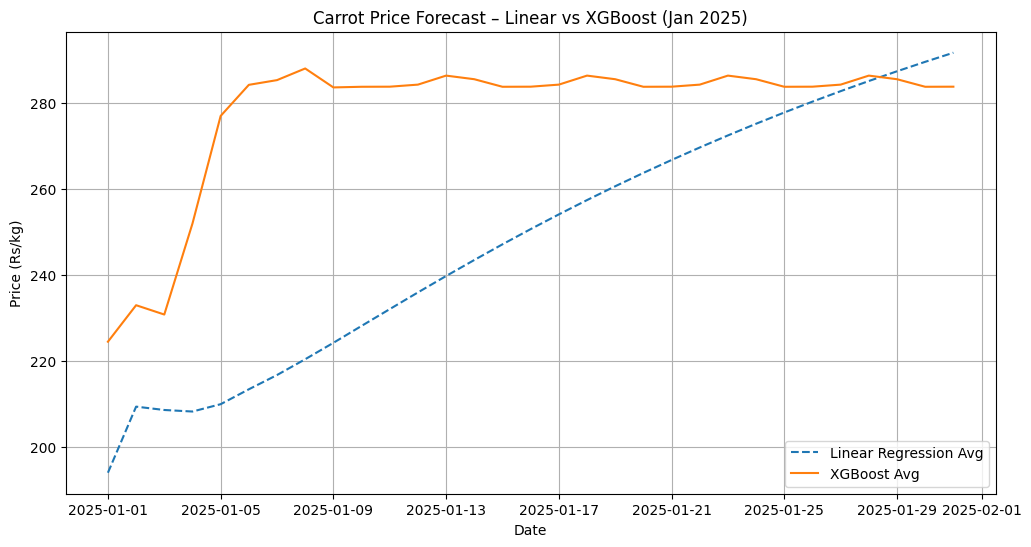

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(comparison_df["Date"], comparison_df["Predicted_Avg_Price"],
         label="Linear Regression Avg", linestyle="--")

plt.plot(comparison_df["Date"], comparison_df["XGB_Pred_Avg"],
         label="XGBoost Avg")

plt.title("Carrot Price Forecast – Linear vs XGBoost (Jan 2025)")
plt.xlabel("Date")
plt.ylabel("Price (Rs/kg)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
###SARIMAX Model Implementation###

In [61]:
df["Carrot_Avg_TS"] = (df["Carrot_Min_Price"] + df["Carrot_Max_Price"]) / 2
ts = df.set_index("Date")["Carrot_Avg_TS"]


In [62]:
exog_cols = [
    "Labour Cost",
    "Transportation Cost",
    "Average of temp_avg_75d",
    "Average of precip_avg_75d",
    "Average of humidity_avg_75d"
]

exog = df.set_index("Date")[exog_cols]


In [63]:
split = int(len(ts) * 0.8)

ts_train, ts_test = ts.iloc[:split], ts.iloc[split:]
exog_train, exog_test = exog.iloc[:split], exog.iloc[split:]


In [66]:
future_exog = exog.iloc[-1:].values.repeat(31, axis=0)
future_exog = pd.DataFrame(future_exog, columns=exog_cols)

future_exog.index = pd.date_range(
    start="2025-01-01",
    periods=31,
    freq="D"
)


In [65]:
sarimax_model = SARIMAX(
    ts_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),  # 🔑 no seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())


c:\Users\asusf\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asusf\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Carrot_Avg_TS   No. Observations:                 1067
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -5629.193
Date:                Sat, 31 Jan 2026   AIC                          11274.386
Time:                        14:23:07   BIC                          11314.144
Sample:                             0   HQIC                         11289.451
                               - 1067                                         
Covariance Type:                  opg                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Labour Cost                    -0.0150      0.088     -0.171      0.864      -0.187       0.157
Transportation Cost            -0.0118      0.003     -3.488      0.000      -0.

In [67]:
sarimax_forecast = sarimax_fit.forecast(
    steps=31,
    exog=future_exog
)

sarimax_forecast


c:\Users\asusf\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\asusf\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


1067    327.385737
1068    329.951402
1069    332.402941
1070    334.745430
1071    336.983720
1072    339.122446
1073    341.166037
1074    343.118724
1075    344.984552
1076    346.767383
1077    348.470910
1078    350.098661
1079    351.654006
1080    353.140165
1081    354.560217
1082    355.917102
1083    357.213630
1084    358.452485
1085    359.636233
1086    360.767326
1087    361.848105
1088    362.880808
1089    363.867575
1090    364.810448
1091    365.711381
1092    366.572237
1093    367.394801
1094    368.180776
1095    368.931788
1096    369.649394
1097    370.335079
Name: predicted_mean, dtype: float64

In [ ]:
###with ranges ###

In [71]:
forecast_df


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price
0,2025-01-01,166.41,221.55,193.98
1,2025-01-02,181.50,237.24,209.37
2,2025-01-03,184.82,232.36,208.59
3,2025-01-04,185.36,231.10,208.23
4,2025-01-05,188.14,231.73,209.94
5,2025-01-06,191.82,235.00,213.41
6,2025-01-07,195.29,238.18,216.73
7,2025-01-08,198.78,242.03,220.41
8,2025-01-09,202.33,246.14,224.23
9,2025-01-10,205.86,250.47,228.17


In [72]:
# Define buffers
MIN_BUFFER = 20
MAX_BUFFER = 35

# Create min price range
forecast_df["Min_Range_Low"] = forecast_df["Predicted_Min_Price"] - MIN_BUFFER
forecast_df["Min_Range_High"] = forecast_df["Predicted_Min_Price"] + MIN_BUFFER

# Create max price range
forecast_df["Max_Range_Low"] = forecast_df["Predicted_Max_Price"] - MAX_BUFFER
forecast_df["Max_Range_High"] = forecast_df["Predicted_Max_Price"] + MAX_BUFFER

forecast_df.head()


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price,Min_Range_Low,Min_Range_High,Max_Range_Low,Max_Range_High
0,2025-01-01,166.41,221.55,193.98,146.41,186.41,186.55,256.55
1,2025-01-02,181.50,237.24,209.37,161.50,201.50,202.24,272.24
2,2025-01-03,184.82,232.36,208.59,164.82,204.82,197.36,267.36
3,2025-01-04,185.36,231.10,208.23,165.36,205.36,196.10,266.10
4,2025-01-05,188.14,231.73,209.94,168.14,208.14,196.73,266.73


In [73]:
forecast_df["Min_Price_Range"] = (
    forecast_df["Min_Range_Low"].round(0).astype(int).astype(str)
    + " - " +
    forecast_df["Min_Range_High"].round(0).astype(int).astype(str)
)

forecast_df["Max_Price_Range"] = (
    forecast_df["Max_Range_Low"].round(0).astype(int).astype(str)
    + " - " +
    forecast_df["Max_Range_High"].round(0).astype(int).astype(str)
)

forecast_df[[
    "Date",
    "Min_Price_Range",
    "Max_Price_Range",
    "Predicted_Avg_Price"
]]


,Date,Min_Price_Range,Max_Price_Range,Predicted_Avg_Price
0,2025-01-01,146 - 186,187 - 257,193.98
1,2025-01-02,162 - 202,202 - 272,209.37
2,2025-01-03,165 - 205,197 - 267,208.59
3,2025-01-04,165 - 205,196 - 266,208.23
4,2025-01-05,168 - 208,197 - 267,209.94
5,2025-01-06,172 - 212,200 - 270,213.41
6,2025-01-07,175 - 215,203 - 273,216.73
7,2025-01-08,179 - 219,207 - 277,220.41
8,2025-01-09,182 - 222,211 - 281,224.23
9,2025-01-10,186 - 226,215 - 285,228.17


In [74]:
real_prices = pd.DataFrame({
    "Date": pd.to_datetime([
        "2025-01-01","2025-01-02","2025-01-03","2025-01-04","2025-01-05",
        "2025-01-06","2025-01-07","2025-01-08","2025-01-09","2025-01-10",
        "2025-01-11","2025-01-12","2025-01-13","2025-01-14","2025-01-15",
        "2025-01-16","2025-01-17","2025-01-18","2025-01-19","2025-01-20",
        "2025-01-21","2025-01-22","2025-01-23","2025-01-24","2025-01-25",
        "2025-01-26","2025-01-27","2025-01-28","2025-01-29"
    ]),
    "Real_Min": [
        180,200,220,150,150,120,170,130,200,150,
        140,160,180,170,180,300,300,300,200,250,
        250,260,250,220,260,250,250,280,240
    ],
    "Real_Max": [
        230,250,250,200,200,240,230,180,240,200,
        160,220,200,200,210,360,360,400,350,320,
        300,300,350,300,350,300,330,350,330
    ]
})


In [75]:
comparison_df = forecast_df.merge(real_prices, on="Date", how="left")
comparison_df.head()


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price,Min_Range_Low,Min_Range_High,Max_Range_Low,Max_Range_High,Min_Price_Range,Max_Price_Range,Real_Min,Real_Max
0,2025-01-01,166.41,221.55,193.98,146.41,186.41,186.55,256.55,146 - 186,187 - 257,180.0,230.0
1,2025-01-02,181.50,237.24,209.37,161.50,201.50,202.24,272.24,162 - 202,202 - 272,200.0,250.0
2,2025-01-03,184.82,232.36,208.59,164.82,204.82,197.36,267.36,165 - 205,197 - 267,220.0,250.0
3,2025-01-04,185.36,231.10,208.23,165.36,205.36,196.10,266.10,165 - 205,196 - 266,150.0,200.0
4,2025-01-05,188.14,231.73,209.94,168.14,208.14,196.73,266.73,168 - 208,197 - 267,150.0,200.0


In [76]:
comparison_df["Min_Inside_Range"] = (
    (comparison_df["Real_Min"] >= comparison_df["Min_Range_Low"]) &
    (comparison_df["Real_Min"] <= comparison_df["Min_Range_High"])
)

comparison_df["Max_Inside_Range"] = (
    (comparison_df["Real_Max"] >= comparison_df["Max_Range_Low"]) &
    (comparison_df["Real_Max"] <= comparison_df["Max_Range_High"])
)


In [77]:
comparison_df[[
    "Date",
    "Real_Min", "Min_Price_Range", "Min_Inside_Range",
    "Real_Max", "Max_Price_Range", "Max_Inside_Range"
]]


,Date,Real_Min,Min_Price_Range,Min_Inside_Range,Real_Max,Max_Price_Range,Max_Inside_Range
0,2025-01-01,180.0,146 - 186,True,230.0,187 - 257,True
1,2025-01-02,200.0,162 - 202,True,250.0,202 - 272,True
2,2025-01-03,220.0,165 - 205,False,250.0,197 - 267,True
3,2025-01-04,150.0,165 - 205,False,200.0,196 - 266,True
4,2025-01-05,150.0,168 - 208,False,200.0,197 - 267,True
5,2025-01-06,120.0,172 - 212,False,240.0,200 - 270,True
6,2025-01-07,170.0,175 - 215,False,230.0,203 - 273,True
7,2025-01-08,130.0,179 - 219,False,180.0,207 - 277,False
8,2025-01-09,200.0,182 - 222,True,240.0,211 - 281,True
9,2025-01-10,150.0,186 - 226,False,200.0,215 - 285,False


In [78]:
min_accuracy = comparison_df["Min_Inside_Range"].mean() * 100
max_accuracy = comparison_df["Max_Inside_Range"].mean() * 100

print(f"Min price range accuracy: {min_accuracy:.2f}%")
print(f"Max price range accuracy: {max_accuracy:.2f}%")


Min price range accuracy: 35.48%
Max price range accuracy: 51.61%


In [81]:
import pandas as pd

# =========================
# 1. Load dataset
# =========================
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Average price
df["Avg_Price"] = (df["Carrot_Min_Price"] + df["Carrot_Max_Price"]) / 2

# =========================
# 2. Compute historical baselines
# =========================
weather_cols = [
    "Average of temp_avg_75d",
    "Average of humidity_avg_75d",
    "Average of precip_avg_75d",
    "Average of windspeed_avg_75d",
    "Average of solarradiation_avg_75d"
]

df["Weather_Index"] = df[weather_cols].mean(axis=1)
weather_mean = df["Weather_Index"].mean()

transport_mean = df["Transportation Cost"].mean()
labour_fert_mean = (
    df["Labour Cost"] +
    df["Fertilizer (Urea)"] +
    df["Fertilizer(MOP)"]
).mean()

# =========================
# 3. Prediction period
# =========================
future_dates = pd.date_range("2025-01-01", "2025-03-31", freq="D")

last_price = df["Avg_Price"].iloc[-1]
last_weather = df["Weather_Index"].iloc[-1]
last_transport = df["Transportation Cost"].iloc[-1]
last_labour_fert = (
    df["Labour Cost"].iloc[-1] +
    df["Fertilizer (Urea)"].iloc[-1] +
    df["Fertilizer(MOP)"].iloc[-1]
)

results = []

# =========================
# 4. FINAL FORMULA (REAL PRICE SPACE)
# =========================
for date in future_dates:

    weather_effect = 0.02 * ((last_weather - weather_mean) / weather_mean)
    transport_effect = 0.015 * ((last_transport - transport_mean) / transport_mean)
    labour_effect = 0.01 * ((last_labour_fert - labour_fert_mean) / labour_fert_mean)

    total_effect = weather_effect + transport_effect + labour_effect

    # Clamp daily movement (important)
    total_effect = max(min(total_effect, 0.05), -0.05)

    avg_price = last_price * (1 + total_effect)

    # Price ranges
    min_price = avg_price * 0.88   # −12%
    max_price = avg_price * 1.15   # +15%

    results.append({
        "Date": date,
        "Predicted_Min_Price": round(min_price, 2),
        "Predicted_Max_Price": round(max_price, 2),
        "Predicted_Avg_Price": round(avg_price, 2)
    })

    last_price = avg_price  # recursive update

forecast_df = pd.DataFrame(results)
forecast_df.head(60)


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price
0,2025-01-01,189.18,247.23,214.98
1,2025-01-02,189.16,247.20,214.96
2,2025-01-03,189.15,247.18,214.94
3,2025-01-04,189.13,247.15,214.92
4,2025-01-05,189.11,247.13,214.90
5,2025-01-06,189.09,247.11,214.88
6,2025-01-07,189.07,247.08,214.85
7,2025-01-08,189.05,247.06,214.83
8,2025-01-09,189.04,247.04,214.81
9,2025-01-10,189.02,247.01,214.79


In [84]:
import pandas as pd
import numpy as np

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# ===============================
# 2. BASIC FEATURES
# ===============================
df["Avg_Price"] = (df["Carrot_Min_Price"] + df["Carrot_Max_Price"]) / 2

# ===============================
# 3. NORMALIZATION HELPERS
# ===============================
def normalize(series):
    return (series - series.mean()) / series.std()

df["Temp_dev"] = normalize(df["Average of temp_avg_75d"])
df["Rain_dev"] = normalize(df["Average of precip_avg_75d"])
df["Humidity_dev"] = normalize(df["Average of humidity_avg_75d"])

df["Labour_dev"] = normalize(df["Labour Cost"])
df["Transport_dev"] = normalize(df["Transportation Cost"])
df["Fertilizer_dev"] = normalize(df["Fertilizer (Urea)"])

# ===============================
# 4. MOMENTUM (3-day)
# ===============================
df["Min_Momentum"] = (df["Carrot_Min_Price"].shift(1) - df["Carrot_Min_Price"].shift(4)) / 3
df["Max_Momentum"] = (df["Carrot_Max_Price"].shift(1) - df["Carrot_Max_Price"].shift(4)) / 3

df.fillna(0, inplace=True)

# ===============================
# 5. PREDICTION LOOP
# ===============================
future_dates = pd.date_range("2025-01-01", "2025-03-31")

last_row = df.iloc[-1]

predictions = []

prev_min = last_row["Carrot_Min_Price"]
prev_max = last_row["Carrot_Max_Price"]

for date in future_dates:

    # ---- Weather index
    weather_index = (
        0.4 * last_row["Temp_dev"] +
        0.3 * last_row["Rain_dev"] +
        0.3 * last_row["Humidity_dev"]
    )

    # ---- Cost index
    cost_index = (
        0.4 * last_row["Labour_dev"] +
        0.4 * last_row["Transport_dev"] +
        0.2 * last_row["Fertilizer_dev"]
    )

    # ---- Momentum
    min_momentum_adj = 0.10 * last_row["Min_Momentum"]
    max_momentum_adj = 0.10 * last_row["Max_Momentum"]

    # ---- Weather & cost adjustments
    weather_adj_min = prev_min * 0.05 * weather_index
    weather_adj_max = prev_max * 0.05 * weather_index

    cost_adj_min = prev_min * 0.03 * cost_index
    cost_adj_max = prev_max * 0.03 * cost_index

    # ---- Final prediction
    pred_min = prev_min + min_momentum_adj + weather_adj_min + cost_adj_min
    pred_max = prev_max + max_momentum_adj + weather_adj_max + cost_adj_max

    # ---- Safety cap (±18%)
    pred_min = np.clip(pred_min, prev_min * 0.82, prev_min * 1.18)
    pred_max = np.clip(pred_max, prev_max * 0.82, prev_max * 1.18)

    predictions.append([
        date,
        round(pred_min, 2),
        round(pred_max, 2),
        round((pred_min + pred_max) / 2, 2)
    ])

    prev_min = pred_min
    prev_max = pred_max


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# ===============================
# 6. RESULTS
# ===============================
pred_df = pd.DataFrame(
    predictions,
    columns=["Date", "Predicted_Min_Price", "Predicted_Max_Price", "Predicted_Avg_Price"]
)
from IPython.display import display
display(pred_df)

pred_df


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price
0,2025-01-01,187.93,260.68,224.31
1,2025-01-02,196.21,271.83,234.02
2,2025-01-03,204.85,283.48,244.17
3,2025-01-04,213.88,295.63,254.76
4,2025-01-05,223.30,308.32,265.81
5,2025-01-06,233.14,321.57,277.36
6,2025-01-07,243.41,335.41,289.41
7,2025-01-08,254.14,349.85,302.00
8,2025-01-09,265.33,364.93,315.13
9,2025-01-10,277.03,380.68,328.85


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price
0,2025-01-01,187.93,260.68,224.31
1,2025-01-02,196.21,271.83,234.02
2,2025-01-03,204.85,283.48,244.17
3,2025-01-04,213.88,295.63,254.76
4,2025-01-05,223.30,308.32,265.81
5,2025-01-06,233.14,321.57,277.36
6,2025-01-07,243.41,335.41,289.41
7,2025-01-08,254.14,349.85,302.00
8,2025-01-09,265.33,364.93,315.13
9,2025-01-10,277.03,380.68,328.85
